## SciPro ID: 2026SS_07

# Homework_3: The Interaction Between Two Atoms

***

### Imports:

In [1]:
import pandas as pd

***

### Task 1:
The goal of this task is to load the QM target data for $Ar_2$ into a Pandas DataFrame and prepare it for the the following calculations.

The input file `CybulskiT19999_Ar2.csv` contains the distances in Angstrom and the energies, in Hartree, which Cybulski and Toczyłowski determined using quantum mechanics (QM). The data is cleaned by removing duplicate rows and rows with missing values.


In [2]:
input_data = pd.read_csv('CybulskiT1999_Ar2.csv', header=0, sep=';')

ar2_calculations = input_data.dropna()
ar2_calculations = ar2_calculations.drop_duplicates()

The potential energies given are originally in Hartree and have to be converted to kJ/mol using the following formula:

$$E_{kJ/mol} = E_{Hartree} \cdot 2625.5$$
where:
- $E_{kJ/mol}$ is the converted potential energy in **kilojoules per mole**
- $E_{Hartree}$ is the QM energy in **Hartree**

In [3]:
ar2_calculations["QM V(r) (kJ/mol)"] = ar2_calculations["QM V(r) (Hartree)"] * 2625.5

ar2_calculations

,R (Å),QM V(r) (Hartree),QM V(r) (kJ/mol)
2,3.000,0.003055,8.020850
3,3.250,0.000518,1.360298
4,3.500,-0.000279,-0.732462
5,3.750,-0.000441,-1.157373
7,3.775,-0.000442,-1.160130
8,3.800,-0.000441,-1.158686
9,3.850,-0.000436,-1.145269
10,4.000,-0.000400,-1.049150
11,4.250,-0.000313,-0.822097
13,4.500,-0.000232,-0.609904


The resulting table contains the cleaned distances, the original QM energies in Hartree, and the converted energies in kJ/mol. These values are used as the reference data for the Lennard-Jones calculation and the later visualization. 

***

### Task 2:
The goal of this task is to calculate the Lennard-Jones potential energy for the same distances that are used in the QM target data.

The Lennard-Jones potential describes the interaction energy between two atoms depending on their distance.

For this we will use following equation:
$$
 V_{LJ}(r) = 4\epsilon \left[  (\frac{\sigma}{r})^{12} - (\frac{\sigma}{r})^6\right]
$$
where:
- $V_{LJ}(r)$ is the Lennard-Jones potential energy in **kJ/mol**,
- $epsilon$ is the energy well depth in **kJ/mol**,
- $sigma$ is the distance where the potential energy becomes zero in **Å**,
- $r$ is the actual distance between the two Argon atoms in **Å**.

The Argon parameters used here are literature values originally given in ergs and cm and have been converted to more modern units$^{[4]}$:
- $\epsilon$ = 0.995 kJ/mol,
- $\sigma$ = 3.405 Å.


In [4]:
def lennard_jones(epsilon, sigma, r):
    ''' doc string and isinstance and typeending incoming '''
    return( 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6))

In [5]:
epsilon = 0.995
sigma = 3.405
lj_energies = []

for index, row in ar2_calculations.iterrows():
    r = row.iloc[0]
    lj_energies.append(lennard_jones(epsilon, sigma, r))

In [6]:
ar2_calculations['Lennard-Jones V(r) (kJ/mol)'] = lj_energies
ar2_calculations

,R (Å),QM V(r) (Hartree),QM V(r) (kJ/mol),Lennard-Jones V(r) (kJ/mol)
2,3.000,0.003055,8.020850,9.681427
3,3.250,0.000518,1.360298,1.697631
4,3.500,-0.000279,-0.732462,-0.513554
5,3.750,-0.000441,-1.157373,-0.980470
7,3.775,-0.000442,-1.160130,-0.989095
8,3.800,-0.000441,-1.158686,-0.993766
9,3.850,-0.000436,-1.145269,-0.993171
10,4.000,-0.000400,-1.049150,-0.938155
11,4.250,-0.000313,-0.822097,-0.774204
13,4.500,-0.000232,-0.609904,-0.606786


***

### Task 3:

<Axes: title={'center': 'title'}, xlabel='Distances R (Å)', ylabel='QM V(r) (kJ/mol)'>

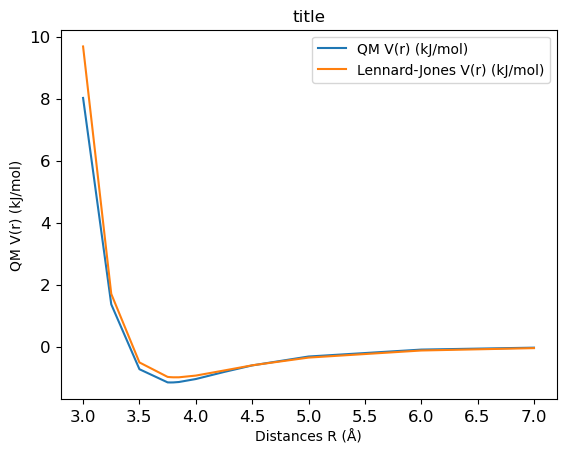

In [7]:
ar2_calculations.plot(x='R (Å)', y=['QM V(r) (kJ/mol)', 'Lennard-Jones V(r) (kJ/mol)'], kind='line',
                      xlabel='Distances R (Å)', ylabel='QM V(r) (kJ/mol)',
                      title='title', fontsize=12)


***

### Task 4:

In [8]:
ar2_calculations.to_csv('Lennard_Jones_Ar2.csv',
                        sep=',', index=False, encoding='utf-8')

In [9]:
testframe = pd.read_csv('Lennard_Jones_Ar2.csv', header=0, sep=',')
testframe

,R (Å),QM V(r) (Hartree),QM V(r) (kJ/mol),Lennard-Jones V(r) (kJ/mol)
0,3.000,0.003055,8.020850,9.681427
1,3.250,0.000518,1.360298,1.697631
2,3.500,-0.000279,-0.732462,-0.513554
3,3.750,-0.000441,-1.157373,-0.980470
4,3.775,-0.000442,-1.160130,-0.989095
5,3.800,-0.000441,-1.158686,-0.993766
6,3.850,-0.000436,-1.145269,-0.993171
7,4.000,-0.000400,-1.049150,-0.938155
8,4.250,-0.000313,-0.822097,-0.774204
9,4.500,-0.000232,-0.609904,-0.606786


***

## References:

[1] 

[2]

[3]